Montar Google Drive e importar librerías



In [4]:
# 1. Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Importar librerías necesarias
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

Mounted at /content/drive
TensorFlow Version: 2.20.0


Cargar el dataset con Data Augmentation

In [5]:
# Ruta a la carpeta que contiene las 7 subcarpetas de productos
data_dir = '/content/drive/MyDrive/dataset_supermercado'

# Configuración de Data Augmentation para entrenamiento y validación
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # Normalización adecuada para MobileNetV2
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # 80% entrenamiento, 20% validación
)

# Cargar imágenes de entrenamiento
train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Cargar imágenes de validación
val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print(f"\nClases detectadas ({num_classes}):", train_generator.class_indices)

Found 176 images belonging to 7 classes.
Found 42 images belonging to 7 classes.

Clases detectadas (7): {'alimento_gato': 0, 'arena_gato': 1, 'libro': 2, 'peluche_garfield': 3, 'shampoo': 4, 'vaso_vidrio': 5, 'zapato': 6}


Construcción de la Red Neuronal (MobileNetV2)

In [6]:
# 1. Cargar el modelo base preentrenado sin la última capa
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Congelar los pesos de la red preentrenada
base_model.trainable = False

# 2. Agregar la cabeza de clasificación (Top Layers)
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

# 3. Compilar el modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Entrenamiento del Modelo

In [7]:
# Callbacks para evitar overfitting y guardar el mejor modelo
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = callbacks.ModelCheckpoint(
    'modelo_caja_supermercado.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Entrenar el modelo
epochs = 20
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3539 - loss: 1.8907
Epoch 1: val_accuracy improved from None to 0.92857, saving model to modelo_caja_supermercado.h5



Epoch 1: finished saving model to modelo_caja_supermercado.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 82s 7s/step - accuracy: 0.5000 - loss: 1.4447 - val_accuracy: 0.9286 - val_loss: 0.4060
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7984 - loss: 0.6582
Epoch 2: val_accuracy improved from 0.92857 to 1.00000, saving model to modelo_caja_supermercado.h5



Epoch 2: finished saving model to modelo_caja_supermercado.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.8693 - loss: 0.4576 - val_accuracy: 1.0000 - val_loss: 0.0740
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9527 - loss: 0.1995
Epoch 3: val_accuracy did not improve from 1.00000
11/11 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.9602 - loss: 0.1649 - val_accuracy: 1.0000 - val_loss: 0.0191
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9634 - loss: 0.1258
Epoch 4: val_accuracy did not improve from 1.00000
11/11 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.9716 - loss: 0.0979 - val_accuracy: 1.0000 - val_loss: 0.0152
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9790 - loss: 0.0475
Epoch 5: val_accuracy did not improve from 1.00000
11/11 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.9830 - loss: 0.0514 - val_accuracy: 1.0000 - val_loss: 0.0115
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9990 - loss:

Visualizar la precisión y pérdida durante el entrenamiento

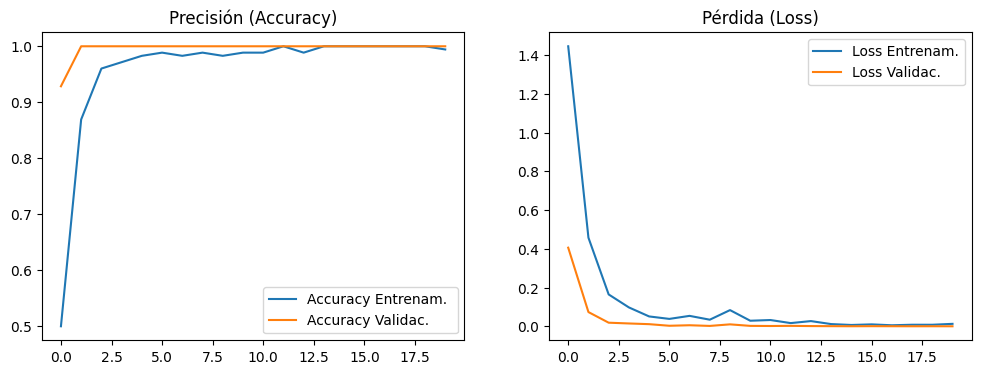

In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))

# Gráfico de Precisión
plt.subplot(1, 2, 1)
plt.plot(acc, label='Accuracy Entrenam. ')
plt.plot(val_acc, label='Accuracy Validac.')
plt.legend(loc='lower right')
plt.title('Precisión (Accuracy)')

# Gráfico de Pérdida
plt.subplot(1, 2, 2)
plt.plot(loss, label='Loss Entrenam.')
plt.plot(val_loss, label='Loss Validac.')
plt.legend(loc='upper right')
plt.title('Pérdida (Loss)')

plt.show()

Matriz de Confusión y Reporte de Métricas

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
=== REPORTE DE CLASIFICACIÓN ===
                  precision    recall  f1-score   support

   alimento_gato       1.00      1.00      1.00         7
      arena_gato       1.00      1.00      1.00         6
           libro       1.00      1.00      1.00         6
peluche_garfield       1.00      1.00      1.00         8
         shampoo       1.00      1.00      1.00         6
     vaso_vidrio       1.00      1.00      1.00         3
          zapato       1.00      1.00      1.00         6

        accuracy                           1.00        42
       macro avg       1.00      1.00      1.00        42
    weighted avg       1.00      1.00      1.00        42



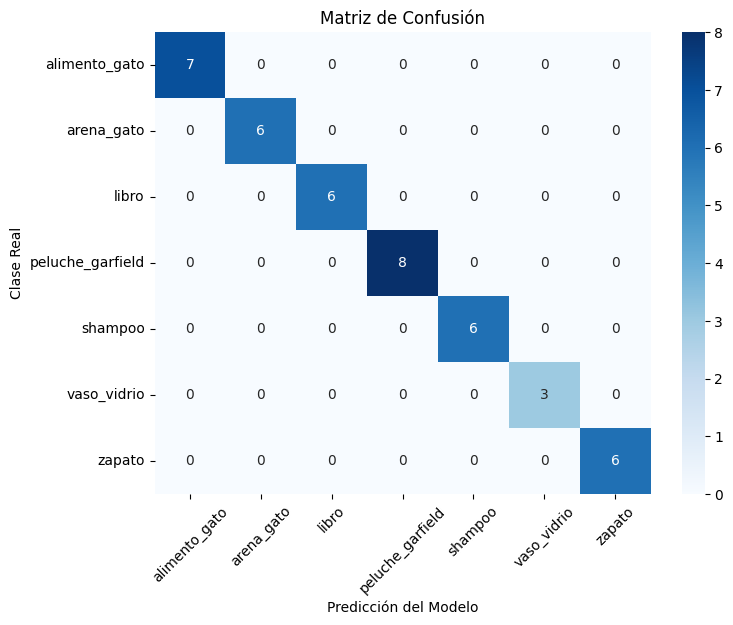

In [9]:
# Cargar predicciones del conjunto de validación
val_generator.reset()
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

class_labels = list(val_generator.class_indices.keys())

# Reporte de Clasificación (Precision, Recall, F1-Score, Accuracy)
print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Matriz de Confusión
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real')
plt.title('Matriz de Confusión')
plt.xticks(rotation=45)
plt.show()

Guardar el modelo y el mapeo de clases para la Caja Registradora

In [10]:
# Save model in .keras format as well
model.save('modelo_caja_supermercado.keras')

# Guardar el índice de las clases en un archivo JSON para la interfaz
class_indices = train_generator.class_indices
# Invertir el diccionario para buscar por índice: {0: 'alimento_gato', 1: 'arena_gato', ...}
labels_map = {v: k for k, v in class_indices.items()}

with open('clases_supermercado.json', 'w') as f:
    json.dump(labels_map, f)

print(" Modelo y clases guardados correctamente.")

 Modelo y clases guardados correctamente.


Interfaz de la Caja Registradora Inteligente

In [11]:
# 1. Instalar Gradio si no está instalado
!pip install -q gradio

import gradio as gr
import numpy as np
import json
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from PIL import Image

# 2. Cargar el modelo entrenado y los índices de clases
model = tf.keras.models.load_model('modelo_caja_supermercado.keras')

with open('clases_supermercado.json', 'r') as f:
    labels_map = json.load(f)

# Convertir llaves a enteros
labels_map = {int(k): v for k, v in labels_map.items()}

# 3. Diccionario oficial de precios
PRECIOS = {
    'alimento_gato': 1.25,
    'arena_gato': 3.00,
    'shampoo': 4.50,
    'peluche_garfield': 3.50,
    'vaso_vidrio': 2.10,
    'libro': 15.00,
    'zapato': 20.00
}

# Variable global para acumular las compras
carrito = []

# 4. Función para generar el ticket en texto
def generar_ticket():
    if not carrito:
        return "--- CARRITO VACÍO ---"

    ticket = "===============================\n"
    ticket += "    SUPERMERCADO INTELIGENTE   \n"
    ticket += "===============================\n"
    total = 0.0
    for i, (item, precio) in enumerate(carrito, 1):
        nombre_formateado = item.replace('_', ' ').title()
        ticket += f"{i}. {nombre_formateado:<18} ${precio:>5.2f}\n"
        total += precio
    ticket += "-------------------------------\n"
    ticket += f"TOTAL A PAGAR:          ${total:>5.2f}\n"
    ticket += "==============================="
    return ticket

# 5. Función principal de escaneo
def escanear_producto(imagen):
    global carrito
    if imagen is None:
        return " Por favor, coloca un objeto frente a la cámara o sube una imagen.", generar_ticket()

    # Preprocesar la imagen para MobileNetV2
    img = Image.fromarray(imagen).resize((224, 224))
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_preprocessed = preprocess_input(img_array.astype(np.float32))

    # Realizar predicción
    preds = model.predict(img_preprocessed)[0]
    class_idx = np.argmax(preds)
    confianza = float(preds[class_idx])
    nombre_producto = labels_map[class_idx]

    # Umbral de seguridad (60% de certeza mínima)
    if confianza >= 0.60:
        precio = PRECIOS.get(nombre_producto, 0.0)
        carrito.append((nombre_producto, precio))
        nombre_display = nombre_producto.replace('_', ' ').title()

        info_txt = f"###  ¡Producto Registrado!\n"
        info_txt += f"* **Producto:** {nombre_display}\n"
        info_txt += f"* **Precio:** ${precio:.2f}\n"
        info_txt += f"* **Confianza:** {confianza*100:.1f}%"
    else:
        info_txt = f"### ⚠️ No Reconocido\n"
        info_txt += f"El modelo no está suficientemente seguro ({confianza*100:.1f}% de certeza). Intenta enfocar mejor el objeto."

    return info_txt, generar_ticket()

# 6. Función para reiniciar la compra
def limpiar_carrito():
    global carrito
    carrito = []
    return " Carrito limpiado para una nueva compra.", generar_ticket()

# 7. Diseñar la Interfaz Gráfica con Gradio
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🛒 Sistema de Caja Registradora con Visión por Computadora")
    gr.Markdown("Pasa un objeto por el escáner (cámara web o subida de foto) para agregarlo automáticamente al ticket de compra.")

    with gr.Row():
        with gr.Column(scale=1):
            input_img = gr.Image(sources=["webcam", "upload"], type="numpy", label="Escáner de Objetos")
            btn_escanear = gr.Button("🔍 Escanear Producto", variant="primary")
            btn_limpiar = gr.Button("🗑️ Nueva Compra / Limpiar Ticket", variant="secondary")

        with gr.Column(scale=1):
            output_info = gr.Markdown("Esperando escaneo de producto...")
            output_ticket = gr.Textbox(label="Ticket Digital de Compra", lines=12, max_lines=15, interactive=False)

    btn_escanear.click(fn=escanear_producto, inputs=input_img, outputs=[output_info, output_ticket])
    btn_limpiar.click(fn=limpiar_carrito, outputs=[output_info, output_ticket])

# Lanzar la aplicación con enlace público temporal (share=True para grabaciones o pruebas)
demo.launch(share=True, debug=True)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/tmp/ipykernel_1311/3568940096.py:93: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c66bb4d86adab93a2b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://c66bb4d86adab93a2b.gradio.live


Stream Continuo

In [13]:
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import cv2
import numpy as np
import json
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# 1. Cargar modelo y clases
model = tf.keras.models.load_model('modelo_caja_supermercado.keras')
with open('clases_supermercado.json', 'r') as f:
    labels_map = json.load(f)
labels_map = {int(k): v for k, v in labels_map.items()}

PRECIOS = {
    'alimento_gato': 1.25, 'arena_gato': 3.00, 'shampoo': 4.50,
    'peluche_garfield': 3.50, 'vaso_vidrio': 2.10, 'libro': 15.00, 'zapato': 20.00
}

# 2. Código JavaScript para streaming en vivo continuo
def start_live_stream():
  js = Javascript('''
    var video;
    var div = document.createElement('div');
    var stream;

    async function init() {
      video = document.createElement('video');
      video.style.display = 'block';
      stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();
    }

    async function captureFrame() {
      if (!video) await init();
      var canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      return canvas.toDataURL('image/jpeg', 0.8);
    }

    window.captureFrame = captureFrame;
  ''')
  display(js)

start_live_stream()

print(" Detección en VIVO iniciada. Muestra un objeto frente a la cámara...")
print(" Para detener el video, interrumpe la ejecución de la celda en Colab.\n")

# 3. Bucle continuo de inferencia en tiempo real
display_handle = display(None, display_id=True)

while True:
    try:
        # Captura un frame continuo desde el navegador
        data = eval_js('captureFrame()')
        if not data:
            continue

        binary = b64decode(data.split(',')[1])
        img_np = np.frombuffer(binary, dtype=np.uint8)
        frame = cv2.imdecode(img_np, cv2.IMREAD_COLOR)

        # Preprocesar frame
        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (224, 224))
        img_array = np.expand_dims(img_resized, axis=0)
        img_preprocessed = preprocess_input(img_array.astype(np.float32))

        # Inferencia
        preds = model.predict(img_preprocessed, verbose=0)[0]
        class_idx = np.argmax(preds)
        confianza = float(preds[class_idx])
        nombre_producto = labels_map[class_idx]

        # Dibujar resultados sobre la pantalla
        if confianza >= 0.60:
            precio = PRECIOS.get(nombre_producto, 0.0)
            texto = f"{nombre_producto.replace('_', ' ').title()}: ${precio:.2f} ({confianza*100:.0f}%)"
            color = (0, 255, 0) # Verde
        else:
            texto = "Buscando producto..."
            color = (0, 0, 255) # Rojo

        # Dibujar rectángulo y texto informativo en la imagen
        cv2.rectangle(frame, (10, 10), (frame.shape[1]-10, 60), (0,0,0), -1)
        cv2.putText(frame, texto, (20, 45), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

        # Mostrar frame actualizado en Colab
        _, encoded_img = cv2.imencode('.jpg', frame)
        display_handle.update(Image(data=encoded_img.tobytes()))

    except Exception as e:
        print(" Transmisión finalizada.")
        break

<IPython.core.display.Javascript object>

 Detección en VIVO iniciada. Muestra un objeto frente a la cámara...
 Para detener el video, interrumpe la ejecución de la celda en Colab.



None

 Transmisión finalizada.


Cámara capturando imagen tras imagen en tiempo real y desplegará en la pantalla el nombre del producto y el precio superpuesto directamente sobre el video

<IPython.core.display.Javascript object>

 Escáner en VIVO activo.
 Haz clic en '🔴 APAGAR CÁMARA' o detén la celda para finalizar.



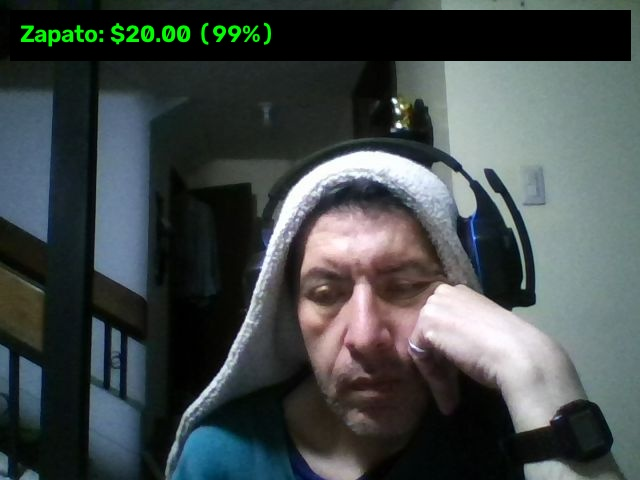


 Cámara apagada con éxito.


In [17]:
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import json
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# 1. Cargar modelo y clases
model = tf.keras.models.load_model('modelo_caja_supermercado.keras')
with open('clases_supermercado.json', 'r') as f:
    labels_map = json.load(f)
labels_map = {int(k): v for k, v in labels_map.items()}

PRECIOS = {
    'alimento_gato': 1.25, 'arena_gato': 3.00, 'shampoo': 4.50,
    'peluche_garfield': 3.50, 'vaso_vidrio': 2.10, 'libro': 15.00, 'zapato': 20.00
}

# 2. JavaScript con botón para detener el hardware de la cámara
def start_live_stream():
  js = Javascript('''
    var video;
    var div = document.createElement('div');
    var stream;
    window.stopCamera = false;

    async function init() {
      video = document.createElement('video');
      video.style.display = 'none';
      stream = await navigator.mediaDevices.getUserMedia({video: true});

      // Botón para apagar cámara desde la interfaz
      var btn = document.createElement('button');
      btn.textContent = '🔴 APAGAR CÁMARA';
      btn.style.padding = '8px 15px';
      btn.style.backgroundColor = '#ff4b4b';
      btn.style.color = 'white';
      btn.style.border = 'none';
      btn.style.borderRadius = '5px';
      btn.style.cursor = 'pointer';
      btn.style.marginBottom = '10px';

      btn.onclick = function() {
        if (stream) {
          stream.getTracks().forEach(track => track.stop()); // Apaga la luz de la cámara
        }
        window.stopCamera = true;
        div.remove();
      };

      document.body.appendChild(div);
      div.appendChild(btn);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();
    }

    async function captureFrame() {
      if (window.stopCamera) return null;
      if (!video) await init();
      var canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      return canvas.toDataURL('image/jpeg', 0.8);
    }

    window.captureFrame = captureFrame;
  ''')
  display(js)

start_live_stream()

print(" Escáner en VIVO activo.")
print(" Haz clic en '🔴 APAGAR CÁMARA' o detén la celda para finalizar.\n")

# 3. Bucle continuo
display_handle = display(None, display_id=True)

while True:
    try:
        data = eval_js('captureFrame()')
        if not data:
            print("\n Cámara apagada con éxito.")
            break

        binary = b64decode(data.split(',')[1])
        img_np = np.frombuffer(binary, dtype=np.uint8)
        frame = cv2.imdecode(img_np, cv2.IMREAD_COLOR)

        # Preprocesamiento e Inferencia
        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (224, 224))
        img_array = np.expand_dims(img_resized, axis=0)
        img_preprocessed = preprocess_input(img_array.astype(np.float32))

        preds = model.predict(img_preprocessed, verbose=0)[0]
        class_idx = np.argmax(preds)
        confianza = float(preds[class_idx])
        nombre_producto = labels_map[class_idx]

        # Etiquetado condicional
        if confianza >= 0.60:
            precio = PRECIOS.get(nombre_producto, 0.0)
            texto = f"{nombre_producto.replace('_', ' ').title()}: ${precio:.2f} ({confianza*100:.0f}%)"
            cv2.rectangle(frame, (10, 10), (frame.shape[1]-10, 60), (0, 0, 0), -1)
            cv2.putText(frame, texto, (20, 42), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

        _, encoded_img = cv2.imencode('.jpg', frame)
        display_handle.update(Image(data=encoded_img.tobytes()))

    except Exception as e:
        print("\n Transmisión finalizada.")
        break